In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"juanholguinmejia","key":"efbf87e9e6451af0cbaeeda1336e38ae"}'}

**configurar Kaggle en Colab**

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)


**descargar el dataset**

In [4]:
!kaggle datasets download -d blastchar/telco-customer-churn


Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 78.1MB/s]



**descomprimir**

In [5]:
import zipfile

with zipfile.ZipFile('telco-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall()


**leer el archivo**

In [6]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')



In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#ANÁLISIS EXPLORATORIO

In [8]:
df.shape

(7043, 21)

In [9]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

El dataset contiene 7,043 registros y 21 variables, de las cuales 20 corresponden a variables independientes y 1 a la variable objetivo (Churn). En cuanto a los tipos de datos, se identifican 2 variables numéricas enteras (int64), 1 variable numérica continua (float64) y 18 variables categóricas (object). Según la información mostrada, no se observan valores nulos en ninguna de las variables.

**Nota:** Se identifica un problema de tipado en "TotalCharges", que figura como object cuando debería ser numérica — esto sugiere la presencia de valores no numéricos que deberán convertirse y tratarse antes del modelado. La variable customerID no aporta valor predictivo y será descartada. La variable objetivo Churn está en formato texto (Yes/No) y requerirá codificación binaria.

In [9]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


Las variables numéricas muestran una alta variabilidad entre los clientes. En particular, **tenure** presenta un rango amplio (0 a 72 meses), lo que indica la coexistencia de clientes nuevos y antiguos. Por otro lado, **MonthlyCharges** también evidencia dispersión en los niveles de gasto (pagos que se realizan en el mes), sugiriendo distintos segmentos de clientes. Finalmente, la variable **SeniorCitizen** muestra que solo alrededor del 16% de los clientes pertenecen a este grupo, lo que indica un desbalance en esta característica. (la mayoría de clientes son entre jovenes y adultos)

VALORES NULOS

In [10]:
#Identificar si tenemos datos nulos
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


inexistencia de valores nulos

#**4. VALORES ÚNICOS**

In [11]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].value_counts())
    print("------")

customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
------
gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
------
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
------
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
------
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
------
OnlineBackup
OnlineBackup
No       

Aunque no se identifican valores nulos explícitos, la variable "TotalCharges" presenta valores vacíos representados como espacios en blanco, lo que indica la presencia de datos faltantes no detectados inicialmente. En cuanto a las variables categóricas, se observan categorías especiales como ‘No internet service’, que reflejan condiciones específicas del cliente más que simples valores categóricos. Adicionalmente, se evidencia un predominio de contratos mensuales y un desbalance moderado en la variable objetivo (Churn), con una mayor proporción de clientes que no abandonan el servicio.”

**Nota:** En las variables "OnlineSecurity", "TechSupport" y "DeviceProtection" se identifica una tercera categoría llamada "No internet service" esto es estructuralmente redundante con "InternetService" = No, por lo que ha de considerar en la etapa de codificación.

En "Contract" (tipo de contrato) se revela que más de la mitad de los clientes opera bajo modalidad mes a mes, lo cual es relevante para el "churn". Además, Se confirman 11 valores en blanco en "TotalCharges", que serán tratados en el preprocesamiento. Finalmente, Churn presenta un desbalance notable: 73% de clientes que no abandona, frente a un 27% que sí lo hace, lo que condicionará la elección de métricas y estrategia de modelado.

#**Limpieza de datos**

**Tratamiento de variable TotalCharges**

*"Cambio de la tipología de la variable TotalCharges*

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Se realiza el cambio de la tipología de la variable TotalCharges, pasando de ser object a float64

observamos que casillas contienen ahora el valor NaN

In [13]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


miramos la relación existente entre los meses que llevan como clientes aquellas personan que tienen la variable totalchanges con valores NaN

In [14]:
df[df['TotalCharges'].isnull()]['tenure']


,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


Se verifica que los 11 registros con TotalCharges nulo corresponden a clientes con tenure = 0, es decir, clientes que no completaron su primer mes de servicio y por tanto no generaron un cargo total registrado. Dado que se trata de valores ausentes con una causa estructural y no de errores aleatorios, se decide eliminar estas filas. Imputar a través de la media o mediana no sería apropiado, ya que TotalCharges es una variable que depende del consumo real del cliente — asignarle un valor artificial distorsionaría la relación entre esta variable y el churn. La eliminación es justificable además por su peso insignificante: 11 registros representan apenas el 0.15% del dataset.

**Eliminamos valores NaN de la variable Totalchange**

In [15]:
df = df[df['TotalCharges'].notnull()]
df.shape


(7032, 21)

pasamos ahora de 7043 filas a 7032.

*Reseteamos el indice para evitar posibles huecos en dataset.*

In [16]:
df.reset_index(drop=True, inplace=True)


**Tratamiento de variables redundantes**

*categoria "No internet service" de las variables "OnlineSecurity", "TechSupport" y "DeviceProtection", "OnlineBackup","StreamingTV", "StreamingMovies"*

In [17]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    print(f"\n{col}")
    print(df[col].value_counts())



OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

TechSupport
TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

StreamingMovies
StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64


In [18]:
df['InternetService'].value_counts()


,count
InternetService,
Fiber optic,3096
DSL,2416
No,1520


Nota: Inicialmente se identificaron 1526 registros con la categoría ‘No internet service’. Tras la eliminación de 11 registros con valores faltantes en TotalCharges, esta cantidad se redujo a 1520, lo que indica que parte de los registros eliminados correspondían a clientes sin servicio de internet. No obstante, se mantiene la consistencia en la relación entre esta categoría y la variable InternetService, confirmando que ambas representan la misma condición.

Por tanto, aunque la categoría ‘No internet service’ representa una condición distinta, se verificó que esta está completamente determinada por la variable InternetService. En particular, la categoría InternetService = No coincide en cantidad con los registros etiquetados como ‘No internet service’ en las variables derivadas, lo que indica que ambas representan la misma condición. Por este motivo, se optó por simplificar dichas variables reemplazando ‘No internet service’ por ‘No’, con el fin de evitar redundancia y reducir la complejidad del modelo sin pérdida de información relevante.


*Cambio de la categoría "No internet service" por la categoría "No"*

In [19]:
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    df[col] = df[col].replace({'No internet service': 'No'})


**Churn (entendamos la variable objetivo)**

In [20]:
df['Churn'].value_counts()


,count
Churn,
No,5163
Yes,1869


se identifica en la variable objetivo churn para las categorías "No" y "Yes" el número correspondiente a los clientes que han abandonado el servicio o que no lo han hecho.

se encuentra que para la categoría "No" pertenecen 5163 del total de clientes y para la categoría "Yes" 1869. esto implica que la mayoría de clientes permanecen con el servicio.

*Porcentaje de clientes que permanecen y no permanecen con los servicios*

In [21]:
df['Churn'].value_counts(normalize=True)


,proportion
Churn,
No,0.734215
Yes,0.265785


Se observa que aproximadamente el 73% de los clientes permanecen en el servicio, mientras que el 27% han abandonado (churn). Esto indica la presencia de un desbalance moderado en la variable objetivo, lo cual debe tenerse en cuenta en etapas posteriores del modelado.

*Gráfico de barras en la variable objetivo "Churn" (Observemos gráficamente el desbalance de la variable)*

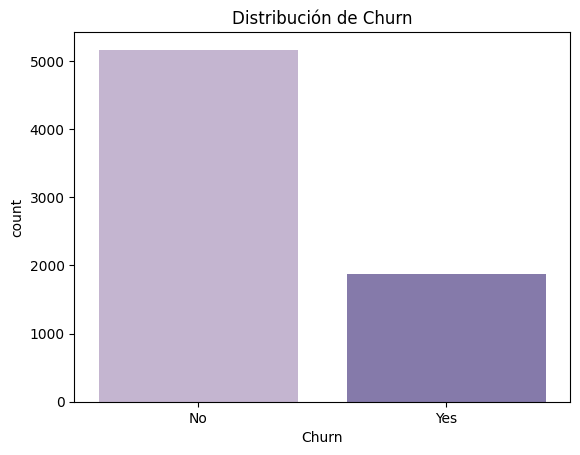

In [22]:
colors = ["#C5B0D5", "#8172B2"]

sns.countplot(x='Churn', data=df, palette=colors)
plt.title('Distribución de Churn')
plt.show()


#**EDA**

#**Histogramas (variables numéricas):**
*Análisis de la distribución individual (sin "churn")*
- tenure
- MonthlyCharges
- TotalCharges

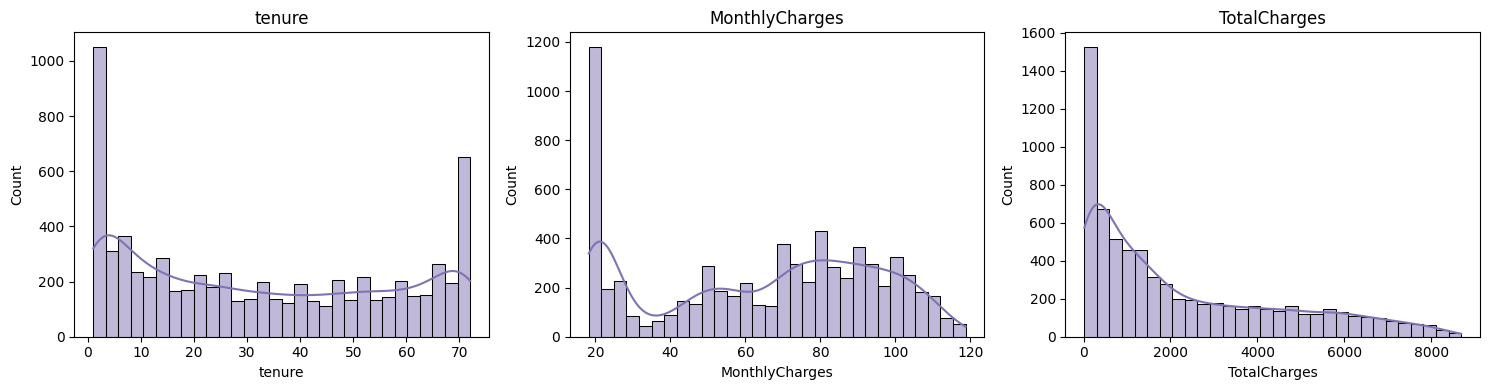

In [23]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15,4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="#8172B2")
    plt.title(f'{col}')

plt.tight_layout()
plt.show()




La variable *tenure* muestra una alta concentración de clientes en los primeros meses, junto con un grupo relevante de clientes antiguos, lo que sugiere diferentes etapas en el ciclo de vida del cliente. Esto podría indicar una posible salida temprana de clientes, aunque debe confirmarse con el análisis de *churn*. Por otro lado, *MonthlyCharges* presenta una distribución amplia, lo que evidencia la existencia de distintos niveles de gasto entre los clientes. Finalmente, *TotalCharges* muestra una fuerte concentración en valores bajos, lo cual está asociado principalmente a la presencia de clientes con baja antigüedad.

#**Boxplot (Variables numéricas)**

*Análisis de la distribución individual (con "churn")*

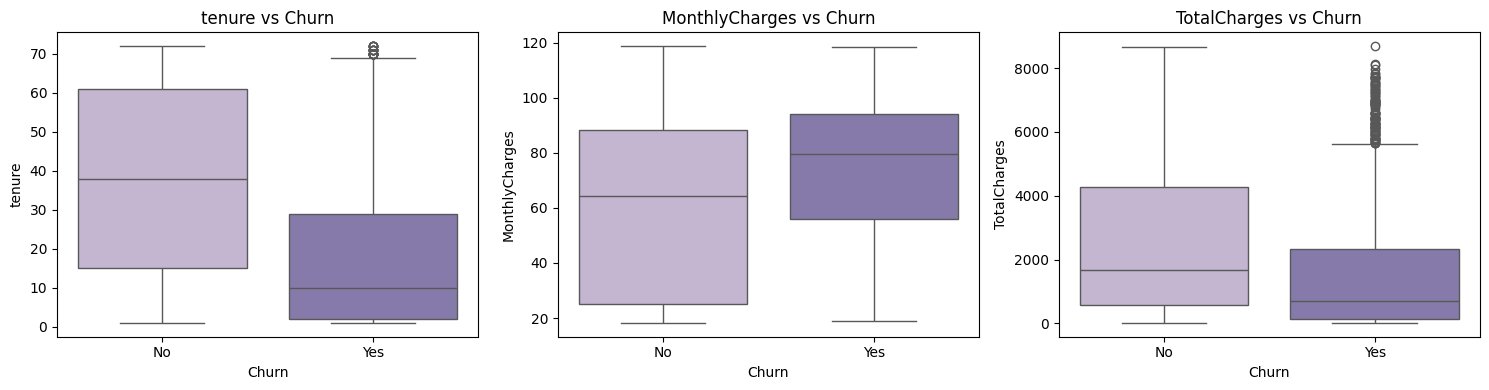

In [24]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15,4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=col, data=df, palette=["#C5B0D5", "#8172B2"])
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

El análisis de los boxplots evidencia que la variable tenure es un fuerte indicador de churn, ya que los clientes que abandonan el servicio presentan una menor antigüedad, mientras que aquellos que permanecen tienden a concentrarse en valores más altos. En cuanto a MonthlyCharges, se observa que los clientes que abandonan tienden a presentar cargos mensuales más elevados, lo que sugiere que precios más altos podrían estar asociados a una mayor probabilidad de churn. Por otro lado, la variable TotalCharges muestra que los clientes que abandonan se concentran en valores bajos, lo cual está directamente relacionado con su baja antigüedad, confirmando que el churn ocurre principalmente en etapas tempranas del ciclo de vida del cliente.

#Barras apiladas (Variables categóricas)

*Análisis de la distribución individual (con "churn")*
- Contract
- InternetService
- PaymentMethod
- PaperlessBilling
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- gender
- SeniorCitizen
- Partner
- Dependents

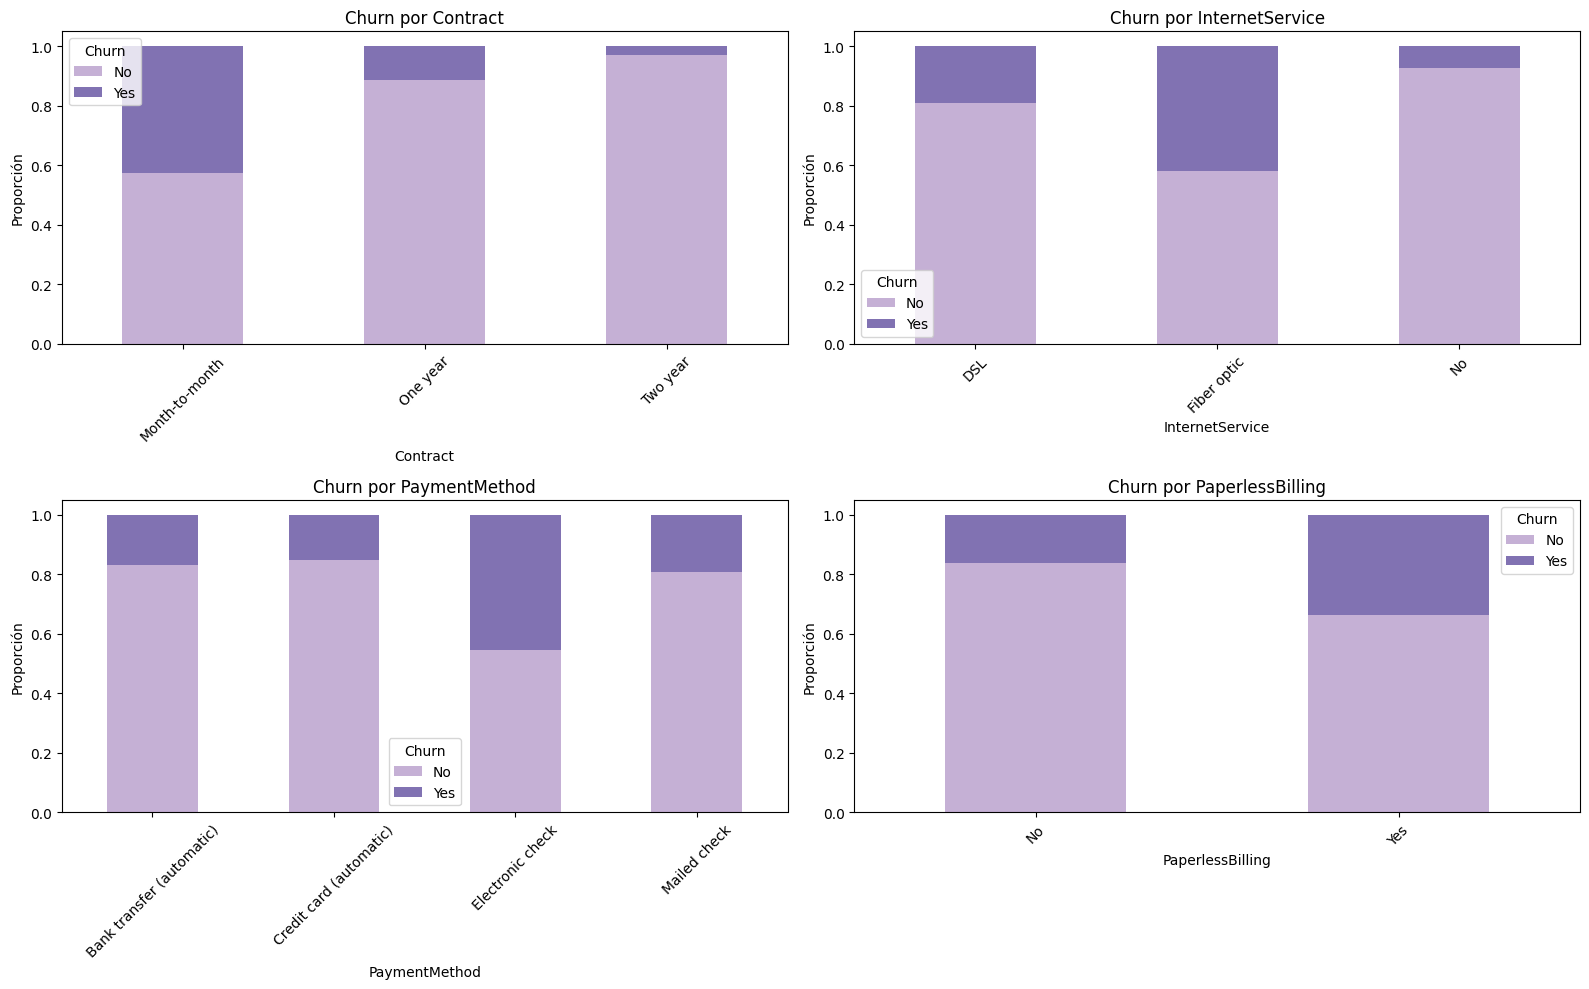

In [25]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']

plt.figure(figsize=(16,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)

    pd.crosstab(df[col], df['Churn'], normalize='index')\
        .plot(kind='bar', stacked=True,
              color=["#C5B0D5", "#8172B2"], ax=plt.gca())

    plt.title(f'Churn por {col}')
    plt.ylabel('Proporción')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El análisis de las variables categóricas revela patrones importantes asociados al churn. En la variable *Contract*, se observa que los clientes con contratos mensuales (‘Month-to-month’) presentan la mayor proporción de abandono, cercana al 50%, mientras que aquellos con contratos de uno o dos años muestran una probabilidad significativamente menor de churn, evidenciando el impacto del compromiso contractual en la retención. En cuanto a *InternetService*, los clientes con servicio de fibra óptica presentan una mayor proporción de churn en comparación con otros tipos de servicio, seguidos por los usuarios de DSL, mientras que los clientes sin servicio de internet muestran bajas tasas de abandono. Por otro lado, en *PaymentMethod*, se identifica que los clientes que utilizan ‘Electronic check’ presentan la mayor proporción de churn, en contraste con otros métodos como transferencia bancaria automática o tarjeta de crédito, que muestran menor abandono. Finalmente, en la variable *PaperlessBilling*, se observa que los clientes con facturación digital (‘Yes’) presentan una mayor proporción de churn en comparación con aquellos que no utilizan este método.

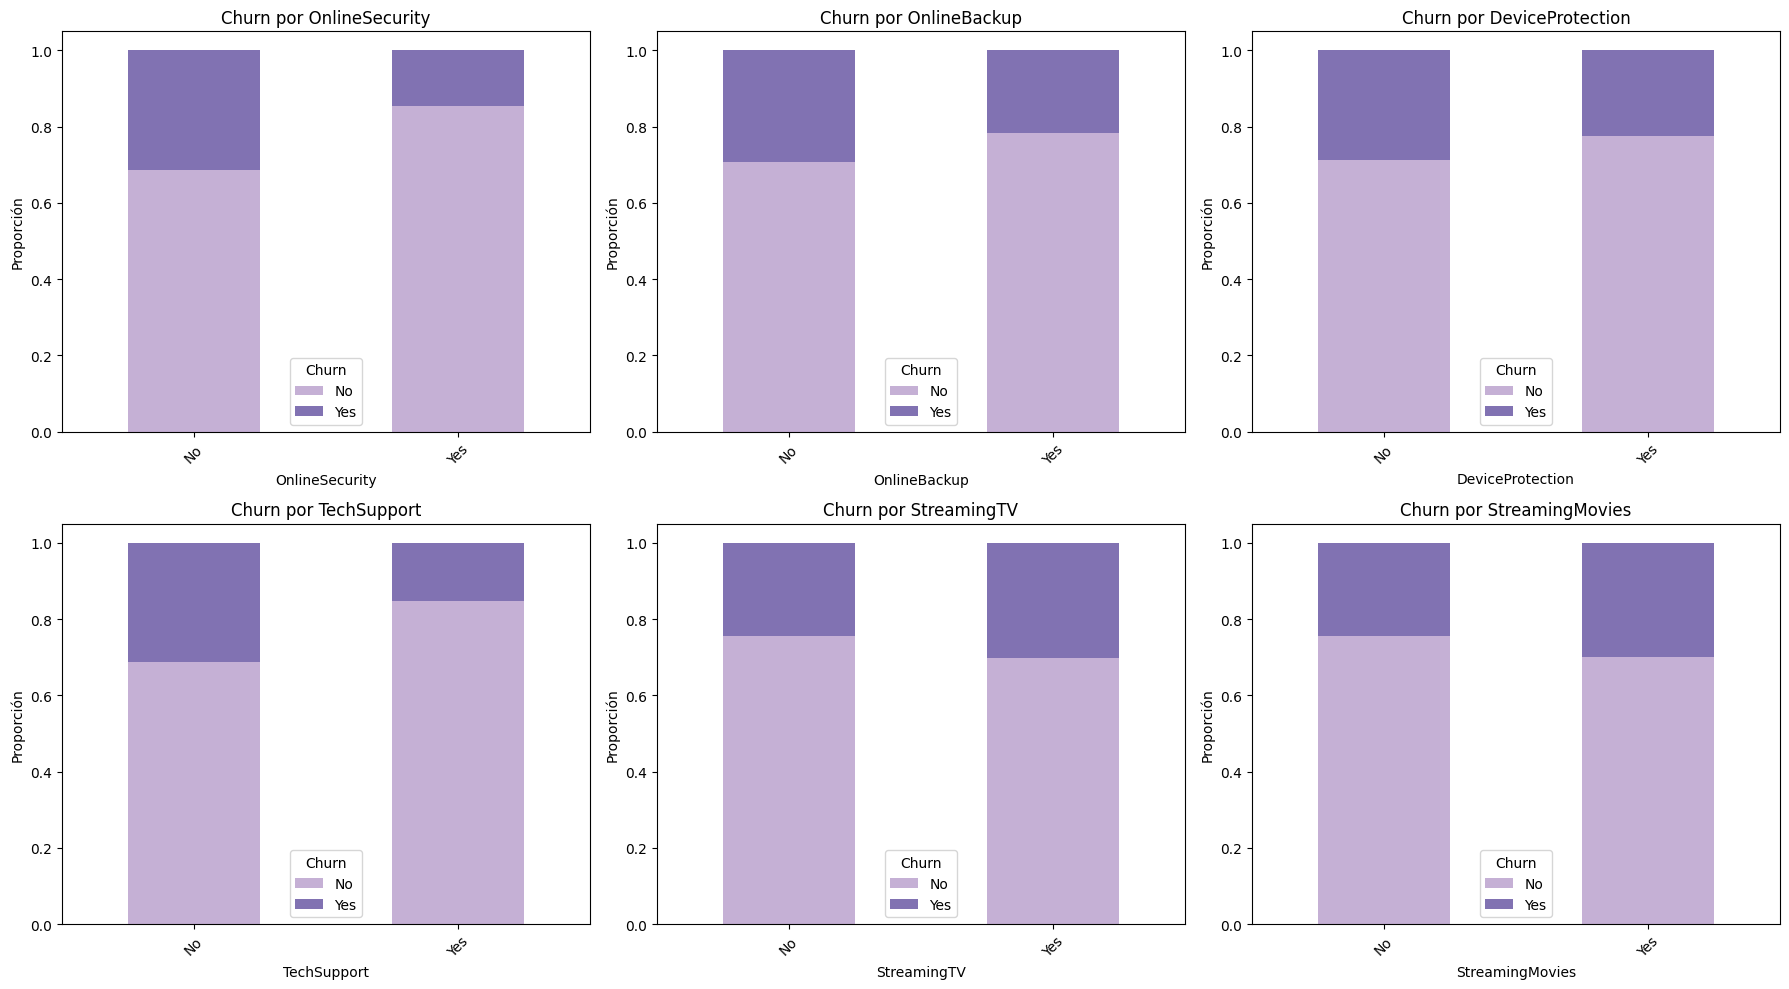

In [26]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

plt.figure(figsize=(18,10))

for i, col in enumerate(service_cols, 1):
    plt.subplot(2, 3, i)

    pd.crosstab(df[col], df['Churn'], normalize='index')\
        .plot(kind='bar', stacked=True,
              color=["#C5B0D5", "#8172B2"], ax=plt.gca())

    plt.title(f'Churn por {col}')
    plt.ylabel('Proporción')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

El análisis de las variables relacionadas con servicios adicionales muestra un patrón claro en el comportamiento del churn. En variables como *OnlineSecurity*, *OnlineBackup*, *DeviceProtection* y *TechSupport*, se observa que los clientes que no cuentan con estos servicios (‘No’) presentan una mayor proporción de abandono, mientras que aquellos que sí los tienen tienden a permanecer en el servicio. Esto sugiere que estos servicios actúan como factores de retención, posiblemente al generar mayor valor percibido o dependencia del servicio.

Por otro lado, en variables como *StreamingTV* y *StreamingMovies*, se observa que los clientes que cuentan con estos servicios (‘Yes’) presentan una mayor proporción de churn. Esto podría indicar que estos servicios, al estar asociados a mayores costos o a un perfil de cliente más exigente, no necesariamente contribuyen a la retención y podrían incluso estar relacionados con una mayor probabilidad de abandono.

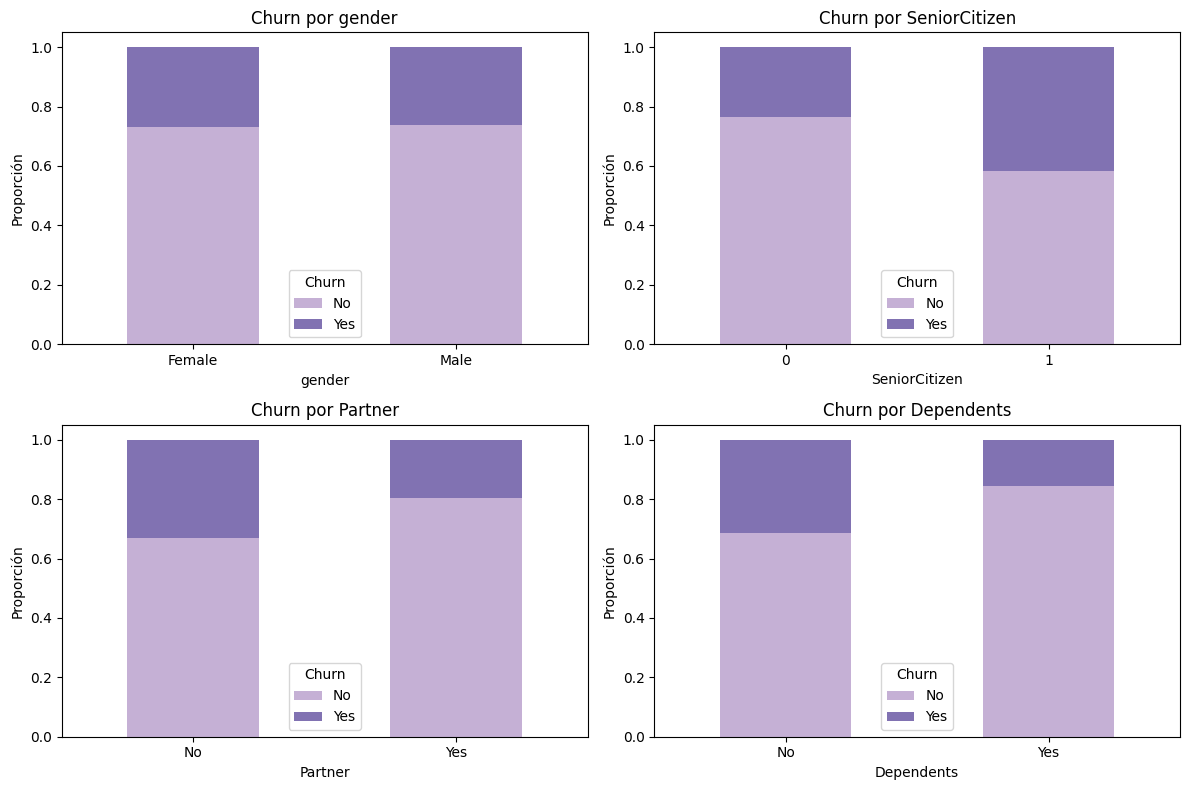

In [27]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

plt.figure(figsize=(12,8))

for i, col in enumerate(demo_cols, 1):
    plt.subplot(2, 2, i)

    pd.crosstab(df[col], df['Churn'], normalize='index')\
        .plot(kind='bar', stacked=True,
              color=["#C5B0D5", "#8172B2"], ax=plt.gca())

    plt.title(f'Churn por {col}')
    plt.ylabel('Proporción')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

El análisis de las variables demográficas muestra que el género (*gender*) no presenta diferencias significativas en la proporción de churn, indicando que no es un factor determinante en el abandono. Por otro lado, los clientes clasificados como adultos mayores (*SeniorCitizen = 1*) presentan una mayor proporción de churn en comparación con los clientes más jóvenes. En cuanto a la variable *Partner*, se observa que los clientes sin pareja presentan una mayor probabilidad de abandono, mientras que aquellos con pareja tienden a permanecer en el servicio. De manera similar, en la variable *Dependents*, los clientes sin dependientes presentan mayores niveles de churn, lo que sugiere que los clientes con responsabilidades familiares tienden a ser más estables.”

#Heatmap de correlación (variables numéricas)

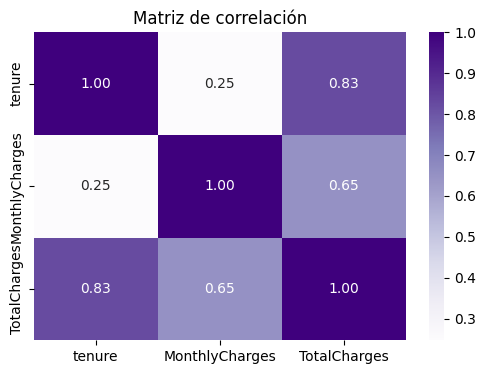

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(),
            annot=True, cmap='Purples', fmt=".2f")

plt.title('Matriz de correlación')
plt.show()

Se evalúa la correlación entre variables numéricas, identificando una alta relación entre tenure y TotalCharges, lo cual es consistente con la naturaleza acumulativa de esta última. No obstante, este análisis no aporta información adicional relevante para la predicción de churn, por lo que no se profundiza en esta relación.

#Eliminación variable CustumerID
es un identificador sin valor predictivo, por tanto no debe entrar al modelo.

In [29]:
df = df.drop('customerID', axis=1)

#**Encoding**

se realiza el encoding de la variale objetivo y las variables categóricas por separado. evitando así ambigüedades en la lectura por parte de python a los datos.

*Encoding Variable objetivo "Churn"*

In [30]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

Encoding Variables categóricas

In [31]:
df = pd.get_dummies(df, drop_first=True)

La variable objetivo Churn fue codificada manualmente asignando No = 0 y Yes = 1, con el fin de mantener control explícito sobre la interpretación de la variable dependiente. Posteriormente, se aplicó One-Hot Encoding al resto de variables categóricas mediante pd.get_dummies.

#Modelos

*División del modelo*

In [32]:
X = df.drop('Churn', axis=1)
y = df['Churn']

*Entrenamiento del modelo*

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

se ha de llevar las variables numéricas a una escala similar (es decir, que sus magnitudes sean comparables). esto para que no me gener problemas en los modelos a utilizar

*escalar variables numéricas*

In [34]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [35]:
scaler = StandardScaler()

El escalado de variables permite que las características numéricas tengan magnitudes comparables, evitando que variables con valores más altos dominen el aprendizaje del modelo. Esto resulta especialmente importante en algoritmos sensibles a la escala, como la regresión logística.

*Ajustamos el esacalado de las variables numéricas a los datos de entrenamiento*

In [36]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Nota: el conjunto de datos se dividió en entrenamiento y prueba bajo una proporción 80/20, aplicando estratificación sobre la variable objetivo para conservar la distribución original de clases. Finalmente, las variables numéricas (tenure, MonthlyCharges y TotalCharges) fueron escaladas mediante StandardScaler, ajustando el escalador únicamente sobre el conjunto de entrenamiento para evitar fuga de información (data leakage).”

#**Primer modelo**

*Regresión logística*

In [37]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Predicción y probabilidad

In [38]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

Evaluación: reporte de clasificación

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[918 115]
 [162 212]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



Clase 0:

- Precision = 0.85
- Recall = 0.89
- F1 = 0.87

El modelo presenta un excelente desempeño para identificar clientes que permanecerán en la compañía. El recall de 89% indica que logra reconocer correctamente la gran mayoría de los clientes que no abandonan el servicio.



Clase 1:

- Precision = 0.65
- Recall = 0.57
- F1 = 0.60

El modelo presenta un desempeño aceptable para identificar clientes que no permanecerán en la compañía. El recall de 57% indica que logra reconocer correctamente solo una cantidad aceptable de los clientes que abandonan el servicio.

Matriz de confusión (gráfica)

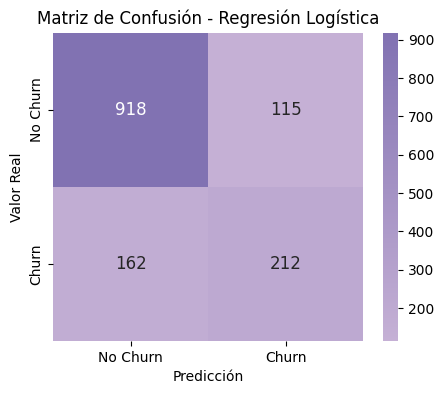

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

# Tus colores
colors = ["#C5B0D5", "#8172B2"]

# Crear colormap personalizado
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_lila", colors
)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    annot_kws={"size":12},
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Regresión Logística")

plt.show()

El modelo identifica correctamente 918 de los 1,033 clientes que no abandonan el servicio (No Churn), clasificando incorrectamente a 115 clientes como churn cuando realmente no lo son. Por otro lado, de los 374 clientes que efectivamente abandonan el servicio (Churn), el modelo logra detectar correctamente 212, mientras que 162 son clasificados erróneamente como clientes que permanecerán en la compañía.

Curva ROC y AUC

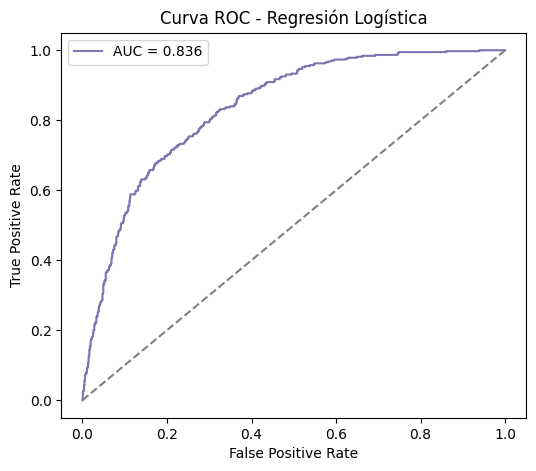

In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    color="#8172B2"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")

plt.legend()

plt.show()

Valor AUC

In [42]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8362


 El modelo presenta un valor ROC-AUC de 0.836, lo que indica una buena capacidad de discriminación entre clientes que abandonan y clientes que permanecen en el servicio. En términos prácticos, existe aproximadamente un 83.6% de probabilidad de que el modelo asigne una puntuación de riesgo más alta a un cliente que realmente hará churn que a uno que no abandonará la compañía. Este resultado evidencia un desempeño sólido como modelo base para la predicción del abandono de clientes.

conclusión: La Regresión Logística alcanzó una precisión global del 80% y un ROC-AUC de 0.836, evidenciando una buena capacidad para diferenciar entre clientes que abandonan y clientes que permanecen en la compañía. El modelo muestra un desempeño sólido en la identificación de clientes que continúan con el servicio; sin embargo, su capacidad para detectar clientes que realmente harán churn es moderada, alcanzando un recall del 57%. Esto implica que una proporción importante de clientes en riesgo de abandono no sería identificada oportunamente, por lo que resulta conveniente explorar modelos más complejos que permitan mejorar la detección de clientes churn.

#**segundo modelo**

*Random Forest*

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predicción y probabilidad

In [44]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

Evaluación: reporte de clasificación

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[923 110]
 [189 185]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Clase 0:

- Precision = 0.83
- Recall = 0.89
- F1 = 0.86

El modelo presenta un excelente desempeño para identificar clientes que permanecerán en la compañía. El recall de 89% indica que logra reconocer correctamente la gran mayoría de los clientes que no abandonan el servicio.

Clase 1:

- Precision = 0.63
- Recall = 0.49
- F1 = 0.55

El modelo presenta un desempeño aceptable para identificar clientes que no permanecerán en la compañía. El recall de 49% indica que logra reconocer correctamente solo una cantidad de los clientes que abandonan el servicio.

Matriz de confusión (gráfica)

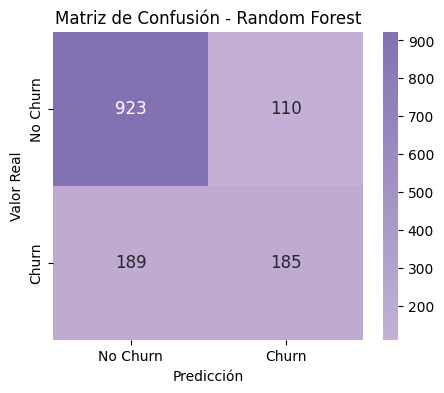

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

colors = ["#C5B0D5", "#8172B2"]

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_lila", colors
)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    annot_kws={"size":12},
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Random Forest")

plt.show()

El modelo identifica correctamente 923 de los 1,033 clientes que no abandonan el servicio (No Churn), clasificando incorrectamente a 110 clientes como churn cuando realmente no lo son. Por otro lado, de los 374 clientes que efectivamente abandonan el servicio (Churn), el modelo logra detectar correctamente 185, mientras que 189 son clasificados erróneamente como clientes que permanecerán en la compañía.

Curva ROC y AUC

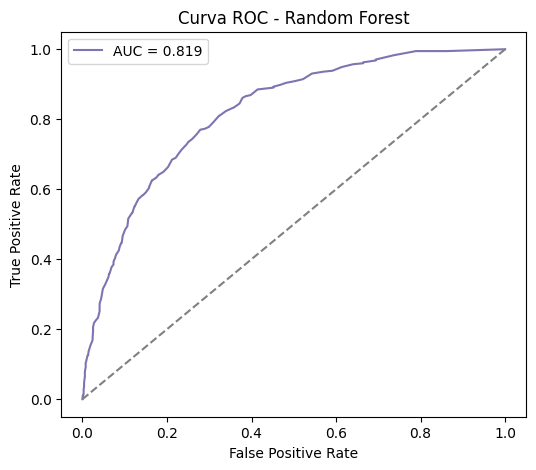

In [47]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    color="#8172B2"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")

plt.legend()

plt.show()

Valor AUC

In [48]:
from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"ROC-AUC: {roc_auc_rf:.4f}")

ROC-AUC: 0.8194


 El modelo presenta un valor ROC-AUC de 0.819, lo que indica una buena capacidad de discriminación entre clientes que abandonan y clientes que permanecen en el servicio. En términos prácticos, existe aproximadamente un 81.9% de probabilidad de que el modelo asigne una puntuación de riesgo más alta a un cliente que realmente hará churn que a uno que no abandonará la compañía. Este resultado evidencia un desempeño sólido como modelo base para la predicción del abandono de clientes.

#**Conclusión:**

Al comparar los modelos evaluados, la Regresión Logística presentó un mejor desempeño general que Random Forest. El modelo logró una mayor capacidad de discriminación (ROC-AUC = 0.836), así como mejores niveles de precisión, recall y F1-score para la detección de clientes churn. Particularmente, la Regresión Logística identificó correctamente el 57% de los clientes que abandonan el servicio, superando el 49% alcanzado por Random Forest. Por esta razón, la Regresión Logística se posiciona como el mejor modelo base para la predicción del abandono de clientes en este conjunto de datos

#**Tercer modelo**

debido a que el modelo sin ajustar le da más importancia a la proporción mayor de datos, que en este caso es churn con el 73%, se ha de realizar un balance sobre los datos a fin de aumentar el recall en la clase churn, la cual representa solo el 27% de los datos. debido que nos interesa que este recall sea mejor.

*Modelo regresión logística ajustado*

In [49]:
log_model_bal = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

log_model_bal.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Predicción y probabilidad

In [50]:
y_pred_bal = log_model_bal.predict(X_test)
y_prob_bal = log_model_bal.predict_proba(X_test)[:,1]

 Evaluación: reporte de clasificación


In [51]:
print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

[[723 310]
 [ 76 298]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



Clase 0:

Precision = 0.90
Recall = 0.70
F1 = 0.79
El modelo presenta un buen desempeño para identificar clientes que permanecerán en la compañía. El recall de 70% indica que logra reconocer correctamente los clientes que no abandonan el servicio.

Clase 1:

Precision = 0.49
Recall = 0.80
F1 = 0.61
El modelo presenta un mejor desempeño para identificar clientes que no permanecerán en la compañía. El recall de 80% indica que logra reconocer correctamente la gran mayoria de los clientes que abandonan el servicio.

Matriz de confusión (gráfica)

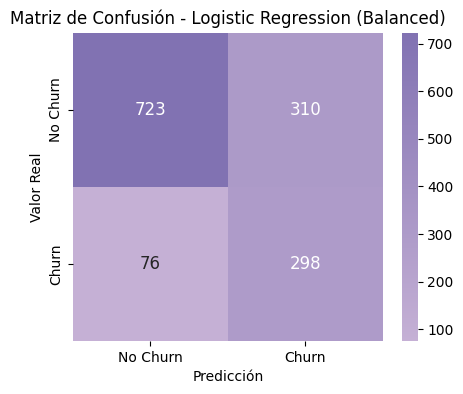

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

# Tus colores
colors = ["#C5B0D5", "#8172B2"]

# Crear colormap personalizado
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_lila", colors
)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    annot_kws={"size":12},
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Logistic Regression (Balanced)")

plt.show()

El modelo identifica correctamente 723 de los 1,033 clientes que no abandonan el servicio (No Churn), clasificando incorrectamente a 310 clientes como churn cuando realmente no lo son. Por otro lado, de los 374 clientes que efectivamente abandonan el servicio (Churn), el modelo logra detectar correctamente 298, mientras que 76 son clasificados erróneamente como clientes que permanecerán en la compañía. esto demuestra, que al balancear los datos, el modelo mejora en recall de clientes que hacen churn, siendo así un modelo mejor para los objetivos de la compañia.

Curva ROC y AUC

In [53]:
from sklearn.metrics import roc_auc_score

roc_auc_bal = roc_auc_score(y_test, y_prob_bal)

print(f"ROC-AUC: {roc_auc_bal:.4f}")

ROC-AUC: 0.8354


El modelo presenta un valor ROC-AUC de 0.8354, lo que indica una buena capacidad de discriminación entre clientes que abandonan y clientes que permanecen en el servicio. En términos prácticos, existe aproximadamente un 83.5% de probabilidad de que el modelo asigne una puntuación de riesgo más alta a un cliente que realmente hará churn que a uno que no abandonará la compañía. Este resultado evidencia un desempeño sólido como modelo base para la predicción del abandono de clientes.

**Conclusión:** El balanceo de clases permitió mejorar significativamente la capacidad del modelo para detectar clientes con riesgo de abandono. El recall de la clase Churn aumentó de 57% a 80%, reduciendo los falsos negativos de 162 a 76 clientes. Aunque esta mejora implicó una disminución de la exactitud global y un incremento en los falsos positivos, el modelo balanceado resulta más adecuado para los objetivos del negocio, ya que minimiza la cantidad de clientes que abandonan el servicio sin ser detectados previamente. Adicionalmente, el ROC-AUC se mantuvo prácticamente estable (0.835), evidenciando que la capacidad discriminatoria del modelo continúa siendo sólida

#**Importancia de variables**

observaremos la importancia de cada una de las variables con respecto al churn,para con ello identificar los factores que aumentan o reducen el churn?

*Extraemos el coeficiente del tercer modelo*

In [54]:
coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_model_bal.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

coeficientes.head(20)

,Variable,Coeficiente
10,InternetService_Fiber optic,0.969598
3,TotalCharges,0.606505
22,PaymentMethod_Electronic check,0.412695
16,StreamingTV_Yes,0.319098
9,MultipleLines_Yes,0.303004
17,StreamingMovies_Yes,0.302895
20,PaperlessBilling_Yes,0.255320
0,SeniorCitizen,0.203380
21,PaymentMethod_Credit card (automatic),0.070889
23,PaymentMethod_Mailed check,0.055386


*Identificamos las variables que más aumentan el churn*

In [55]:
coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
).head(10)

,Variable,Coeficiente
10,InternetService_Fiber optic,0.969598
3,TotalCharges,0.606505
22,PaymentMethod_Electronic check,0.412695
16,StreamingTV_Yes,0.319098
9,MultipleLines_Yes,0.303004
17,StreamingMovies_Yes,0.302895
20,PaperlessBilling_Yes,0.255320
0,SeniorCitizen,0.203380
21,PaymentMethod_Credit card (automatic),0.070889
23,PaymentMethod_Mailed check,0.055386


Gráfico

<Figure size 1000x800 with 0 Axes>

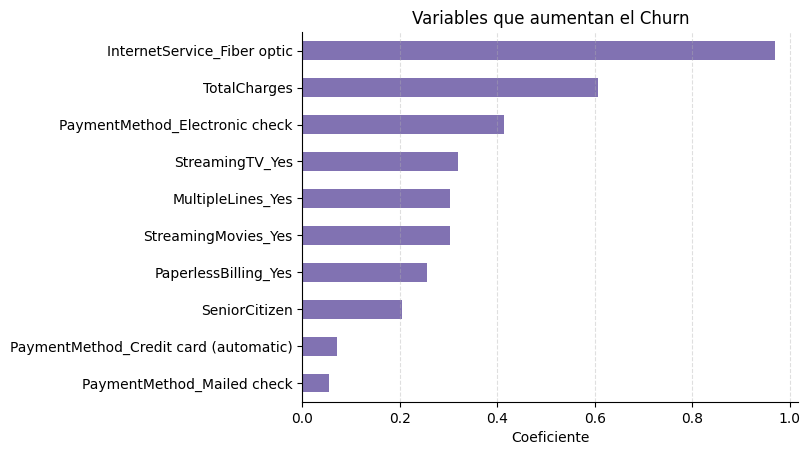

In [58]:
plt.figure(figsize=(10,8))

ax = coeficientes.sort_values(
    by='Coeficiente'
).tail(10).plot(
    x='Variable',
    y='Coeficiente',
    kind='barh',
    color="#8172B2",
    legend=False
)

plt.title('Variables que aumentan el Churn')
plt.xlabel('Coeficiente')
plt.ylabel('')

# Color suave para la grilla
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Eliminar bordes superiores y derechos
sns.despine()

plt.show()

El análisis de coeficientes de la Regresión Logística balanceada evidencia que los principales factores asociados a una mayor probabilidad de abandono son la contratación del servicio de Internet por fibra óptica, los altos cargos acumulados (TotalCharges) y el uso de cheque electrónico como método de pago. Asimismo, servicios adicionales como Streaming TV, Streaming Movies y líneas múltiples muestran una relación positiva con el churn. Estos resultados son consistentes con los hallazgos obtenidos durante el análisis exploratorio, donde dichas categorías presentaban las mayores proporciones de clientes que abandonaban el servicio. En consecuencia, estos segmentos representan grupos prioritarios para el diseño de estrategias de retención

*Identificamos las variables que más disminuyen el churn*

In [57]:
coeficientes.sort_values(
    by='Coeficiente',
    ascending=True
).head(10)

,Variable,Coeficiente
19,Contract_Two year,-1.459829
1,tenure,-1.253082
11,InternetService_No,-1.004825
18,Contract_One year,-0.790945
7,PhoneService_Yes,-0.402842
12,OnlineSecurity_Yes,-0.379381
15,TechSupport_Yes,-0.338226
2,MonthlyCharges,-0.279029
6,Dependents_Yes,-0.227717
13,OnlineBackup_Yes,-0.141711


Gráfico

<Figure size 1000x800 with 0 Axes>

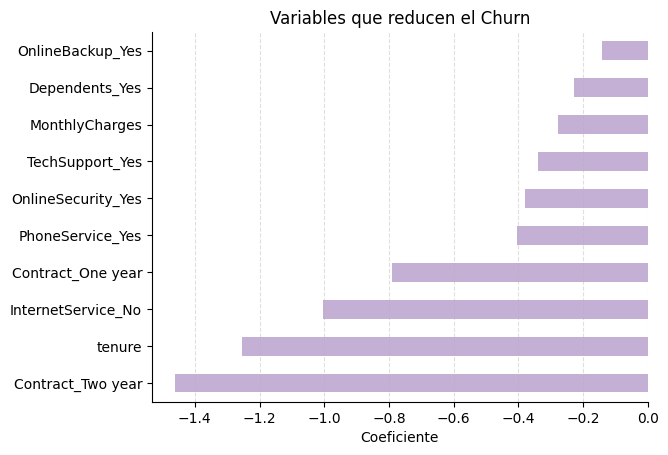

In [63]:
plt.figure(figsize=(10,8))

ax = coeficientes.sort_values(
    by='Coeficiente'
).head(10).plot(
    x='Variable',
    y='Coeficiente',
    kind='barh',
    color="#C5B0D5",
    legend=False
)

plt.title('Variables que reducen el Churn')
plt.xlabel('Coeficiente')
plt.ylabel('')

plt.grid(axis='x', linestyle='--', alpha=0.4)

sns.despine()

plt.show()

Los resultados muestran que los principales factores asociados a una menor probabilidad de abandono son los contratos de largo plazo (uno y dos años), la antigüedad del cliente (tenure) y la ausencia del servicio de internet. Asimismo, contar con servicios complementarios como seguridad en línea (OnlineSecurity), soporte técnico (TechSupport) y respaldo en la nube (OnlineBackup) también contribuye a reducir la probabilidad de churn. De igual forma, los clientes con dependientes presentan una mayor tendencia a permanecer en la compañía. Estos hallazgos sugieren que la fidelización está estrechamente relacionada con la permanencia contractual y con la adopción de servicios que generan mayor valor percibido por parte del cliente.

#**Conclusión:**
El análisis de coeficientes de la Regresión Logística balanceada permitió identificar los principales factores asociados al abandono y permanencia de los clientes. Los contratos de largo plazo y la antigüedad del cliente se consolidan como los mecanismos más efectivos de retención, mientras que el servicio de internet por fibra óptica y el uso de cheque electrónico representan los principales factores de riesgo de churn. Adicionalmente, servicios complementarios como soporte técnico, seguridad en línea y respaldo de información contribuyen a fortalecer la permanencia de los usuarios. Estos hallazgos proporcionan información valiosa para diseñar estrategias de fidelización orientadas a reducir la pérdida de clientes.

#**Conclusión Final**

El presente proyecto tuvo como objetivo desarrollar un modelo de predicción de abandono de clientes (Churn) utilizando información demográfica, contractual y de consumo de servicios de telecomunicaciones.
Durante la etapa de preparación de datos se identificaron valores faltantes en la variable TotalCharges, correspondientes principalmente a clientes nuevos con una antigüedad igual o cercana a cero meses. Debido a que estos registros representaban una proporción mínima del conjunto de datos, se optó por eliminarlos sin afectar significativamente la calidad de la información. Adicionalmente, se realizó la transformación de variables categóricas y la estandarización de variables numéricas para garantizar un adecuado desempeño de los modelos.
El análisis exploratorio permitió identificar patrones relevantes asociados al abandono. Se observó una mayor proporción de churn en clientes con contratos mensuales, usuarios de internet por fibra óptica, clientes que utilizan cheque electrónico como método de pago y personas catalogadas como adultos mayores. Por el contrario, los clientes con contratos de uno o dos años, mayor antigüedad y servicios adicionales como soporte técnico o seguridad en línea presentaron menores tasas de abandono.
Posteriormente se evaluaron diferentes modelos de clasificación. La Regresión Logística obtuvo un desempeño superior al Random Forest en las métricas de interés para el negocio. Tras aplicar balanceo de clases mediante el parámetro class_weight='balanced', el modelo logró incrementar el recall de la clase Churn de 57% a 80%, mejorando significativamente la capacidad de identificar clientes con riesgo de abandono. Aunque esta estrategia redujo la exactitud global del modelo, permitió disminuir considerablemente la cantidad de clientes churn no detectados, aspecto crítico para los objetivos de retención de la compañía.
Finalmente, el análisis de coeficientes permitió identificar los principales factores que incrementan y reducen la probabilidad de abandono, proporcionando información valiosa para la toma de decisiones y el diseño de estrategias de fidelización.

Recomendaciones para la Empresa
1. Fortalecer la migración hacia contratos de largo plazo
Los contratos de uno y dos años fueron los factores que más redujeron la probabilidad de churn. Por ello, se recomienda diseñar campañas comerciales que incentiven la migración desde contratos mensuales hacia planes de mayor permanencia mediante descuentos, beneficios exclusivos o programas de fidelización.

2. Analizar las causas de abandono en clientes con fibra óptica
El servicio de internet por fibra óptica fue el principal factor asociado al churn. Se recomienda investigar aspectos relacionados con calidad del servicio, precios, atención al cliente o expectativas de los usuarios para identificar las causas específicas que están impulsando el abandono en este segmento.

3. Implementar estrategias de retención para clientes nuevos
La antigüedad del cliente mostró una fuerte relación negativa con el churn, indicando que los abandonos ocurren principalmente durante los primeros meses de permanencia. Se recomienda fortalecer los procesos de onboarding, seguimiento temprano y acompañamiento durante los primeros meses del servicio.

4. Promover servicios de valor agregado
Los clientes que cuentan con servicios como soporte técnico, seguridad en línea y respaldo de información presentan una menor probabilidad de abandono. Por esta razón, se recomienda incentivar la adopción de estos servicios mediante promociones o paquetes integrados.

5. Monitorear clientes con métodos de pago de mayor riesgo
Los usuarios que utilizan cheque electrónico mostraron una mayor tendencia al abandono. Este segmento puede considerarse una población prioritaria para campañas preventivas de retención y seguimiento personalizado.
